Extract AE33 zipfiles and save data to parquet files.
Provide plotting functions for data visualization.

joerg.klausen@meteoswiss.ch

In [1]:
import os
import polars as pl
import matplotlib.pyplot as plt
from processing.ae33 import AE33

ae33 = AE33()
root = "/product_data/data/pay/Kenya/MKN/"

AE33 initialized.


Processing source /product_data/data/pay/Kenya/MKN/incoming/ae33/data/2022/01 ...
Processing source /product_data/data/pay/Kenya/MKN/incoming/ae33/data/2022/02 ...
Processing source /product_data/data/pay/Kenya/MKN/incoming/ae33/data/2022/03 ...
Processing source /product_data/data/pay/Kenya/MKN/incoming/ae33/data/2022/04 ...
Processing source /product_data/data/pay/Kenya/MKN/incoming/ae33/data/2022/05 ...
Processing source /product_data/data/pay/Kenya/MKN/incoming/ae33/data/2022/06 ...
Processing source /product_data/data/pay/Kenya/MKN/incoming/ae33/data/2022/07 ...
Processing source /product_data/data/pay/Kenya/MKN/incoming/ae33/data/2022/08 ...
Processing source /product_data/data/pay/Kenya/MKN/incoming/ae33/data/2022/09 ...
Processing source /product_data/data/pay/Kenya/MKN/incoming/ae33/data/2022/10 ...
Processing source /product_data/data/pay/Kenya/MKN/incoming/ae33/data/2022/11 ...
Processing source /product_data/data/pay/Kenya/MKN/incoming/ae33/data/2022/12 ...
{}
Processing so

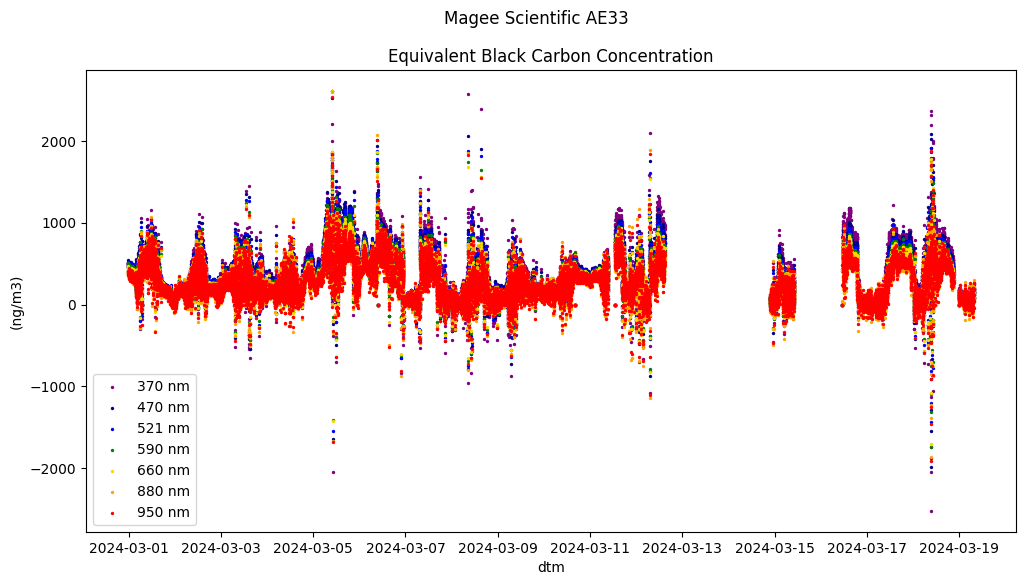

Processing source /product_data/data/pay/Kenya/MKN/incoming/ae33/data/2024/04 ...
Processing source /product_data/data/pay/Kenya/MKN/incoming/ae33/data/2024/05 ...
Processing source /product_data/data/pay/Kenya/MKN/incoming/ae33/data/2024/06 ...
Processing source /product_data/data/pay/Kenya/MKN/incoming/ae33/data/2024/07 ...
Processing source /product_data/data/pay/Kenya/MKN/incoming/ae33/data/2024/08 ...
Processing source /product_data/data/pay/Kenya/MKN/incoming/ae33/data/2024/09 ...
Processing source /product_data/data/pay/Kenya/MKN/incoming/ae33/data/2024/10 ...
Processing source /product_data/data/pay/Kenya/MKN/incoming/ae33/data/2024/11 ...
Processing source /product_data/data/pay/Kenya/MKN/incoming/ae33/data/2024/12 ...
{}
done


In [2]:
# process AE33 data files
years = ["2022", "2023", "2024"]
months = ["{:02d}".format(mm) for mm in range(1, 13, 1)]
for year in years:
    for month in months:
        source = os.path.join(root, "incoming/ae33/data", year, month)
        target = os.path.join("data", "level1", year, month)
        archive = os.path.join(root, "archive/ae33/data", year, month)
        issues = os.path.join(root, "incoming_with_issues/ae33")
        df, errors = ae33.zipfiles_to_parquet(source=source, target=target, archive=archive, issues=issues, plot=True)
    print(errors)
print("done")

In [3]:
df = pl.read_parquet("data/level1/2023/01/ae33.parquet")
df.schema
dtm = "dtm"

statistic,dtm,BC1,BC2,BC3,BC4,BC5,BC6,BC7
str,str,f64,f64,f64,f64,f64,f64,f64
"""count""","""67747""",67747.0,67747.0,67747.0,67747.0,67747.0,67747.0,67747.0
"""null_count""","""0""",0.0,0.0,0.0,0.0,0.0,0.0,0.0
"""mean""","""2022-12-28 13:…",319.378349,311.65132,303.669166,283.030643,271.259347,259.210223,262.128995
"""std""",null,807.476997,837.536997,9157.289968,796.073982,774.316739,775.879054,789.571648
"""min""","""2021-07-04 14:…",-3014.0,-2512.0,-763647.0,-2282.0,-2390.0,-4036.0,-4005.0
"""25%""","""2022-12-14 11:…",34.0,33.0,32.0,30.0,27.0,23.0,21.0
"""50%""","""2022-12-29 15:…",168.0,157.0,148.0,139.0,132.0,129.0,128.0
"""75%""","""2023-01-10 09:…",358.0,335.0,313.0,292.0,279.0,273.0,275.0
"""max""","""2023-01-28 19:…",11762.0,13371.0,1.583972e6,13615.0,14684.0,18197.0,19552.0


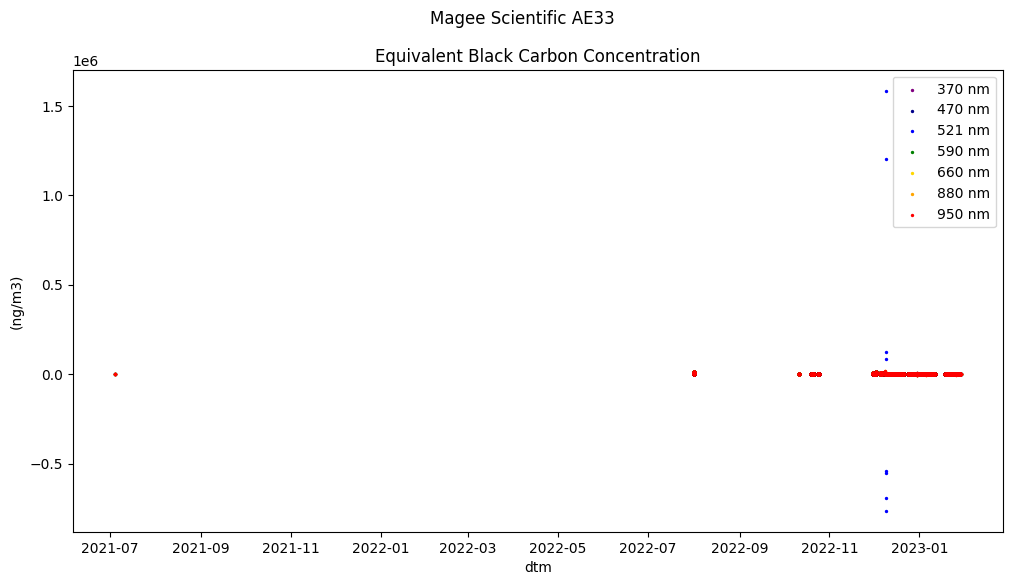

statistic,dtm,flags_BC1,flags_BC2,flags_BC3,flags_BC4,flags_BC5,flags_BC6,flags_BC7
str,str,f64,f64,f64,f64,f64,f64,f64
"""count""","""67747""",67747.0,67747.0,67747.0,67747.0,67747.0,67747.0,67747.0
"""null_count""","""0""",0.0,0.0,0.0,0.0,0.0,0.0,0.0
"""mean""","""2022-12-28 13:…",0.001934,0.002007,0.00214,0.001904,0.001948,0.001491,0.001963
"""std""",null,null,null,null,null,null,null,null
"""min""","""2021-07-04 14:…",0.0,0.0,0.0,0.0,0.0,0.0,0.0
"""25%""","""2022-12-14 11:…",null,null,null,null,null,null,null
"""50%""","""2022-12-29 15:…",null,null,null,null,null,null,null
"""75%""","""2023-01-10 09:…",null,null,null,null,null,null,null
"""max""","""2023-01-28 19:…",1.0,1.0,1.0,1.0,1.0,1.0,1.0


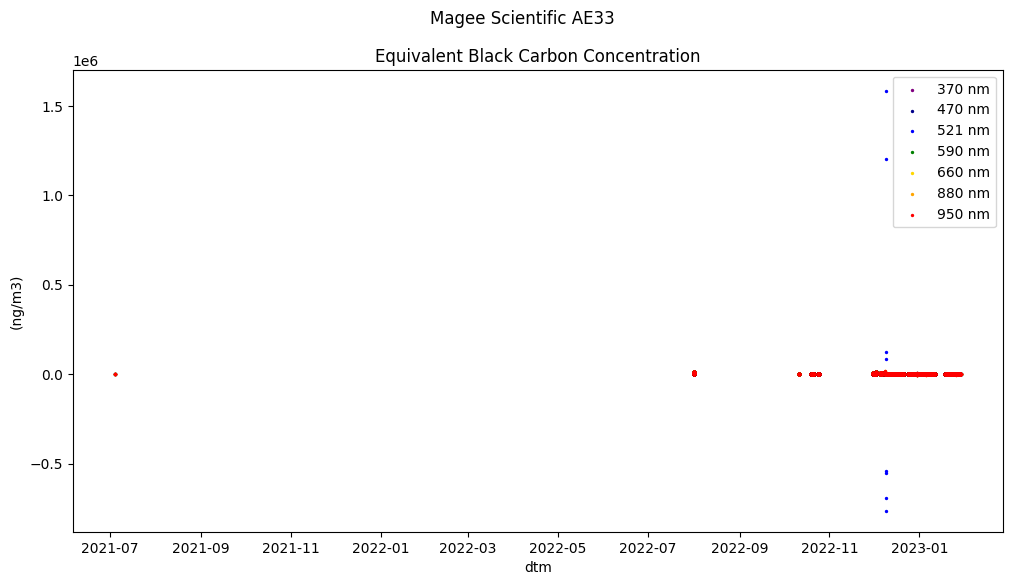

In [4]:
cols = [dtm, "BC1", "BC2", "BC3", "BC4", "BC5", "BC6", "BC7"]
display(df.select(cols).describe())
ae33.plot_aethalometer_data(df)

df_flagged = ae33.flag_spurious_data(df)
cols_flags = [dtm, "flags_BC1", "flags_BC2", "flags_BC3", "flags_BC4", "flags_BC5", "flags_BC6", "flags_BC7"]
display(df_flagged.select(cols_flags).describe())
ae33.plot_aethalometer_data(df_flagged)

In [5]:
# import polars as pl

# def flag_spurious_data(dataframe, value_threshold=0, consecutive_threshold=2):
#     """
#     Flag spurious data in a polars DataFrame consisting of time series data.

#     Parameters:
#     - dataframe: polars DataFrame
#     - value_threshold: threshold for considering values around zero (default: 0)
#     - consecutive_threshold: threshold for consecutive occurrences (default: 2)

#     Returns:
#     - polars DataFrame with an additional 'spurious_flag' column
#     """
#     spurious_flags = []

#     for column in dataframe.columns:
#         # Identify spurious data based on the specified thresholds
#         spurious_mask = (
#             (dataframe[column] <= value_threshold) & 
#             (dataframe[column].shift(-1) > value_threshold) & 
#             (dataframe[column].shift(consecutive_threshold) > value_threshold)
#         ) | (
#             (dataframe[column] <= value_threshold) & 
#             (dataframe[column].shift(1) > value_threshold) & 
#             (dataframe[column].shift(-consecutive_threshold) > value_threshold)
#         )

#         spurious_flags.append(spurious_mask)

#     # Create a new column 'spurious_flag' in the DataFrame
#     dataframe = dataframe.with_column('spurious_flag', pl.col(spurious_flags).any())

#     return dataframe

# # Example usage:
# # Assuming 'your_time_series_data.csv' is your input CSV file
# input_file = 'your_time_series_data.csv'

# # Read the CSV file into a polars DataFrame
# df = pl.read_csv(input_file)

# # Call the function to flag spurious data
# df_with_spurious_flags = flag_spurious_data(df)

# # Display the resulting DataFrame with spurious flags
# print(df_with_spurious_flags)


In [6]:
# # Concatenate the individual DataFrames into a single one
# combined_data = pl.concat(dataframes)

# # Assuming you have datetime columns, replace 'datetime_column' with the actual column name.
# datetime_column = 'timestamp'

# # Perform aggregation by datetime_column
# agg_data = (
#     combined_data
#     .with_column(combined_data[datetime_column].cast(pl.Date32))
#     .groupby(datetime_column)
#     .agg(pl.sum(combined_data['value_column']))
#     .sort(datetime_column)
# )